In [7]:
import os

import numpy as np
import matplotlib.pyplot as plt

In [8]:
os.getcwd()

'/home/rimella/PythonDirectory/Postdoc/Epidemiology/PAL_cineca'

In [9]:
model_A_5000 = np.load("Data/Output/likelihood_eval_A_5000.npy")
model_B_5000 = np.load("Data/Output/likelihood_eval_B_5000.npy")
model_C_5000 = np.load("Data/Output/likelihood_eval_C_5000.npy")
model_A_5000 = model_A_5000[np.where(np.isnan(model_A_5000)==False)]
model_B_5000 = model_B_5000[np.where(np.isnan(model_B_5000)==False)]
model_C_5000 = model_C_5000[np.where(np.isnan(model_C_5000)==False)]

model_A_10000 = np.load("Data/Output/likelihood_eval_A_10000.npy")
model_B_10000 = np.load("Data/Output/likelihood_eval_B_10000.npy")
model_C_10000 = np.load("Data/Output/likelihood_eval_C_10000.npy")
model_A_10000 = model_A_10000[np.where(np.isnan(model_A_10000)==False)]
model_B_10000 = model_B_10000[np.where(np.isnan(model_B_10000)==False)]
model_C_10000 = model_C_10000[np.where(np.isnan(model_C_10000)==False)]

model_A_30000 = np.load("Data/Output/likelihood_eval_A_30000.npy")
model_B_30000 = np.load("Data/Output/likelihood_eval_B_30000.npy")
model_C_30000 = np.load("Data/Output/likelihood_eval_C_30000.npy")
model_A_30000 = model_A_30000[np.where(np.isnan(model_A_30000)==False)]
model_B_30000 = model_B_30000[np.where(np.isnan(model_B_30000)==False)]
model_C_30000 = model_C_30000[np.where(np.isnan(model_C_30000)==False)]

In [10]:
np.log(np.mean(np.exp(model_C_10000 -np.max(model_C_10000)))) + np.max(model_C_10000)

-68638.67619697601

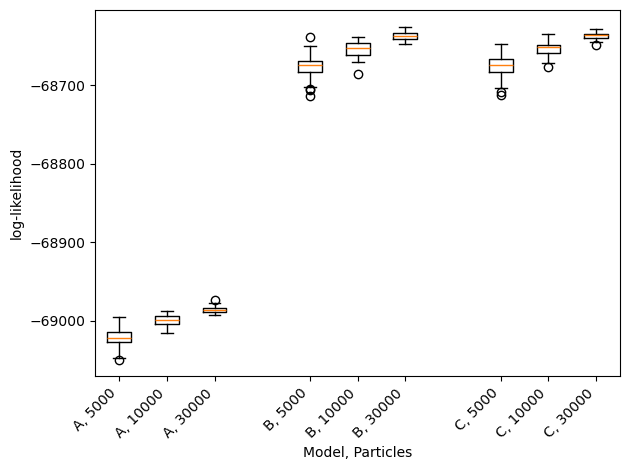

In [11]:
plt.boxplot([model_A_5000, model_A_10000, model_A_30000, model_B_5000, model_B_10000, model_B_30000, model_C_5000, model_C_10000, model_C_30000], 
	    labels= ["A, 5000", "A, 10000", "A, 30000", "B, 5000", "B, 10000", "B, 30000", "C, 5000", "C, 10000", "C, 30000"],
	    positions = [1, 2, 3, 5, 6, 7, 9, 10, 11])
# Rotate labels so they don’t overlap
plt.xticks(rotation=45, ha="right")
# plt.axhline(y = -70000, color = "red")

# Add labels for clarity
plt.xlabel("Model, Particles")
plt.ylabel("log-likelihood")  # change to your actual metric

plt.tight_layout()  # adjusts margins so labels fit
plt.show()

In [20]:
from tabulate import tabulate

In [21]:
table = []

table.append(["A, 5000", "A, 10000", "A, 30000", "B, 5000", "B, 10000", "B, 30000", "C, 5000", "C, 10000", "C, 30000"])

models = [model_A_5000, model_A_10000, model_A_30000, model_B_5000, model_B_10000, model_B_30000, model_C_5000, model_C_10000, model_C_30000]

row = []
for model in models:
	row.append(str(np.round(np.mean(model), 2))+ " ("+str(np.round(np.std(model), 2))+")")

table.append(row)

In [42]:
head = ["Model", "Nr parameters", "Nr particles", "log-likelihood", "AIC"]

table = []
table.append(head)

start  = ["A, 5000", "A, 10000", "A, 30000", "B, 5000", "B, 10000", "B, 30000", "C, 5000", "C, 10000", "C, 30000"]
models = [model_A_5000, model_A_10000, model_A_30000, model_B_5000, model_B_10000, model_B_30000, model_C_5000, model_C_10000, model_C_30000]

nr_parameters = [11, 11, 11, 128, 128, 128, 167, 167, 167]

for i in range(len(models)):

	row_1 = start[i].split(",")

	row = []

	row.append(row_1[0])
	row.append(str(nr_parameters[i]))
	row.append(row_1[1])


	model = models[i]
	row.append(str(np.round(np.mean(model), 2))+ " ("+str(np.round(np.std(model), 2))+")")
	row.append(str(np.round(2*nr_parameters[i] - 2*np.mean(model), 3)))
	table.append(row)

In [43]:
print(tabulate(table, tablefmt="latex_raw"))

\begin{tabular}{lllll}
\hline
 Model & Nr parameters & Nr particles & log-likelihood    & AIC        \\
 A     & 11            & 5000         & -69020.53 (10.88) & 138063.053 \\
 A     & 11            & 10000        & -68999.29 (6.72)  & 138020.577 \\
 A     & 11            & 30000        & -68985.79 (4.35)  & 137993.579 \\
 B     & 128           & 5000         & -68675.8 (12.26)  & 137607.592 \\
 B     & 128           & 10000        & -68654.39 (10.14) & 137564.774 \\
 B     & 128           & 30000        & -68637.55 (4.46)  & 137531.099 \\
 C     & 167           & 5000         & -68675.86 (12.64) & 137685.716 \\
 C     & 167           & 10000        & -68653.32 (8.3)   & 137640.645 \\
 C     & 167           & 30000        & -68637.69 (4.05)  & 137609.373 \\
\hline
\end{tabular}
